# LINEAR REGRESSION

## Taxi trip price prediction

In [9]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [10]:
# loading the dataset
df = pd.read_csv("/content/taxi_trip_pricing (1).csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


## Data Cleaning

In [11]:
# Checking for null values
df[df.isnull()]

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# handling null values
df.dropna(inplace=True)

In [13]:
# dropping duplicate rows
df.drop_duplicates(inplace=True)
df.shape

(562, 11)

In [15]:
# Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,2,0,3.0,1,0,3.56,0.80,0.32,53.82,36.2624
2,36.87,1,1,1.0,0,0,2.70,1.21,0.15,37.27,52.9032
5,8.64,0,1,2.0,2,0,2.55,1.71,0.48,89.33,60.2028
12,41.79,3,1,3.0,0,0,4.60,1.77,0.11,86.95,88.1328
14,9.91,1,0,2.0,0,0,2.32,1.26,0.34,41.72,28.9914


## EDA

<Axes: >

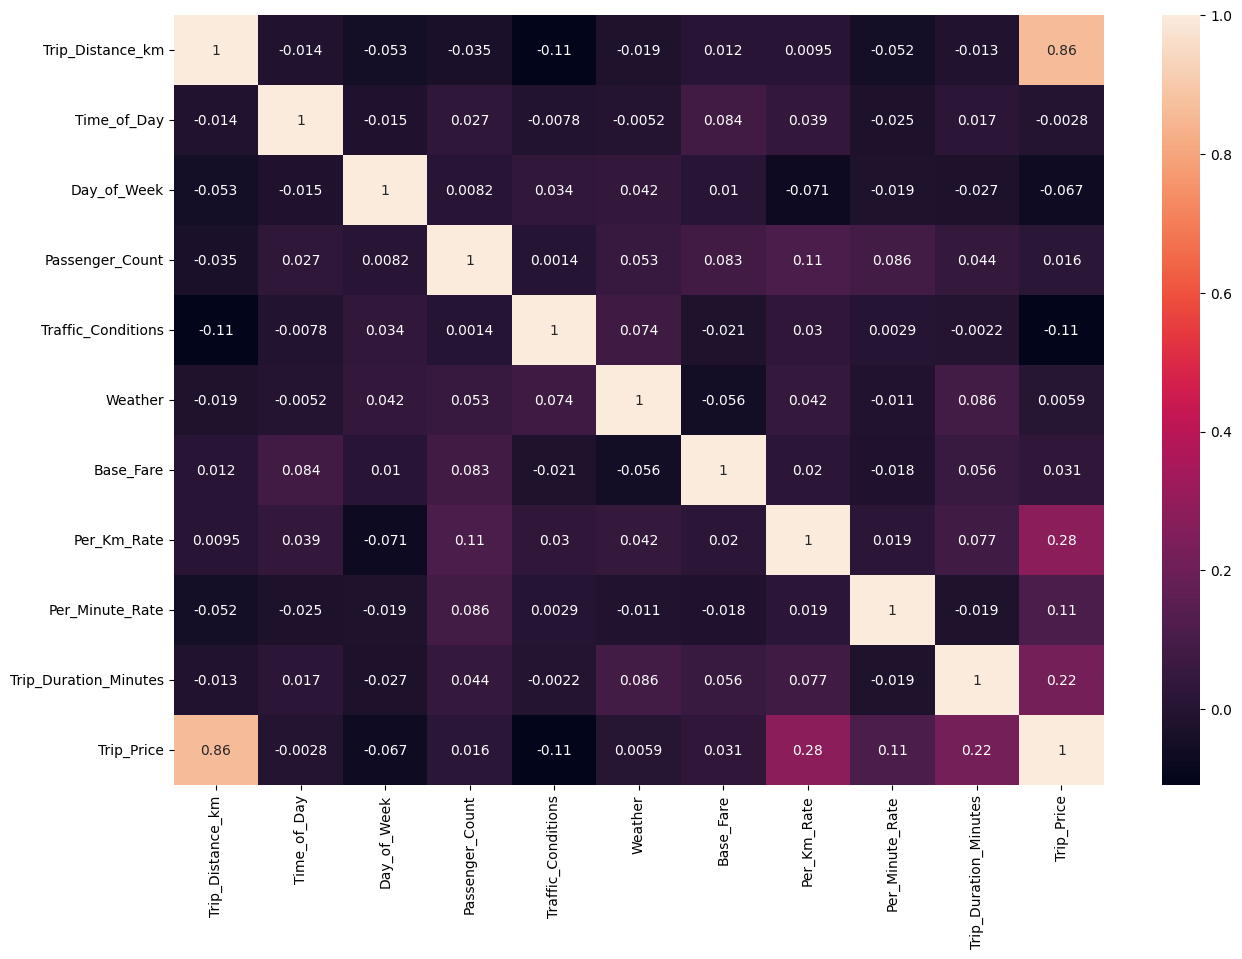

In [16]:
#  Getting Correlation between columns
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True)

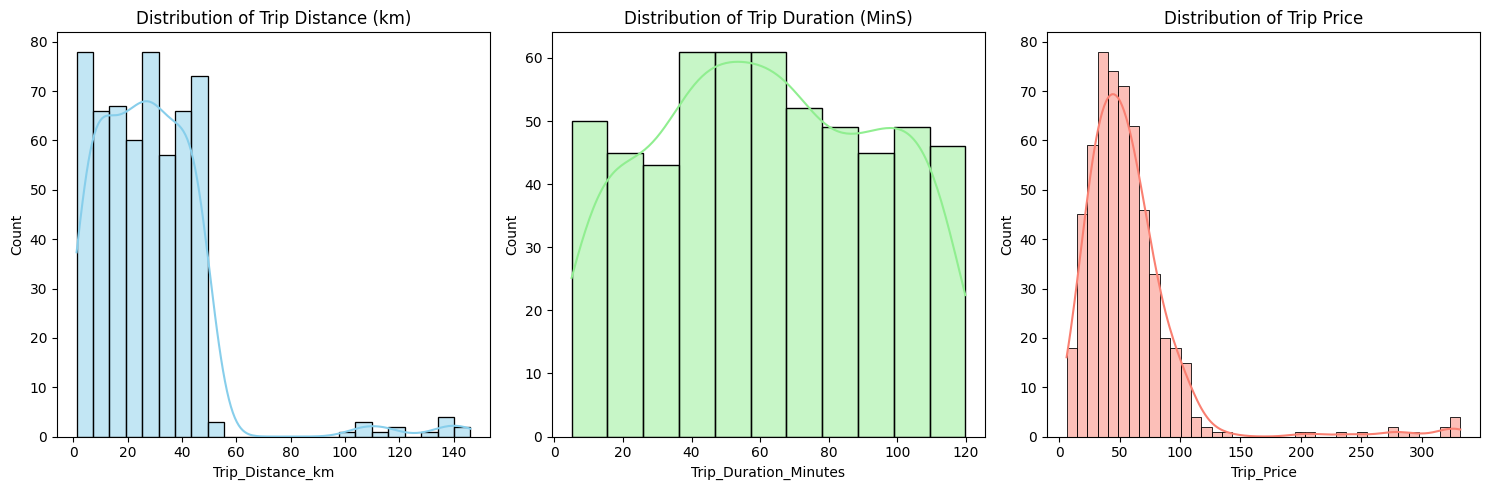

In [25]:
# Create subplots
fig, axes = plt.subplots(1,3,figsize=(15, 5))
# Trip Distance
sns.histplot(x="Trip_Distance_km",data=df,kde=True,ax=axes[0],color="skyblue")
axes[0].set_title("Distribution of Trip Distance (km)")
# Trip Duration
sns.histplot(x="Trip_Duration_Minutes",data=df,kde=True,ax=axes[1],color="lightgreen")
axes[1].set_title("Distribution of Trip Duration (MinS)")
# Trip Price
sns.histplot(x="Trip_Price",data=df,kde=True,ax=axes[2],color="salmon")
axes[2].set_title("Distribution of Trip Price")

plt.tight_layout()
plt.show()


## Model Training

In [17]:
# Dividing data into input and output
X = df.drop("Trip_Price",axis=1)
y = df["Trip_Price"]

In [18]:
# Splitting data for training and testing
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)

In [19]:
# Scaling for better efficiency
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
Xtrain = sc.fit_transform(Xtrain)
Xtest = sc.transform(Xtest)

In [20]:
# model training
model = LinearRegression()
model.fit(Xtrain,ytrain)

LinearRegression()

In [21]:
# Prediction
ypred = model.predict(Xtest)
ypred

array([ 43.83616   , 106.38323826,  45.24026425,  52.59747767,
        37.20927039,   6.34027727,  91.08905103,  38.99329061,
        61.28425053,  80.40672763,  27.56048401,  55.80679014,
        44.86929803,  65.91359002,  20.87791086,  86.60730349,
        77.79256814,  53.7579186 ,  56.59102286,  27.33805141,
        13.84287231,  36.69458119, 101.41356691,  33.09933585,
        59.92831623,  73.20963535,  61.75738119,  56.79289485,
         6.62326125,  89.04049708,  24.25948812,  53.17996201,
        76.00860731,  61.34022451,  61.65094415,  84.67001098,
        92.58104773,  48.74662756, 210.5529364 ,  12.97040372,
        49.8367864 ,  72.29433778,  89.27961986,  95.04705017,
        30.99560773,  64.17699684,  39.48227977,  51.23149958,
        63.60210152,  31.77278747,  75.32454281,  53.91357227,
        21.1993315 ,  -2.2866271 ,  51.62958842, 113.45242073,
        73.8044202 ,  20.36249628,  52.4047193 ,  73.17430935,
        62.4227979 ,  47.0733074 ,  19.68684277,  22.99

In [22]:
# Efficiency
print("Training Eff: ",model.score(Xtrain,ytrain))
print("Testing Eff: ",model.score(Xtest,ytest))

Training Eff:  0.8861476032033012
Testing Eff:  0.8877716566927674


In [23]:
# Performance metrics
print("Metrics: ")
r2 = r2_score(ytest,ypred)
print("R2: ",r2)
N=df.shape[0]
P=df.shape[1]
adj_r2 = 1-(((1-r2**2)*(N-1))/N-P-1)
print("adj R2: ",adj_r2)
print("MSE: ",mean_squared_error(ytest,ypred))
print("MAE: ",mean_absolute_error(ytest,ypred))

Metrics: 
R2:  0.8877716566927674
adj R2:  12.788515492159357
MSE:  243.88022906595302
MAE:  9.663758253018708
